# Supplement 1 — CNC Spindle: from raw vibration to cluster labels

### DBSCAN lecture series · unsupervised learning with scikit-learn

**Companion to the main lecture notebook.** The algorithm is the same; what changes is the
hard part of the job.

> ### The lesson of this notebook
> On a CNC machine, DBSCAN never sees a vibration signal. It sees a handful of numbers you
> computed from that signal. **The features are the model** — the clustering can only find
> structure that your feature extraction has already made visible. Here we build six features
> from raw accelerometer windows and watch three cutting regimes, chatter, and a worn tool
> fall out of the geometry.

---

### The machining problem

A 3-axis vertical machining centre runs a mixed job: roughing, semi-finishing and finishing
passes with a 4-flute end mill. A triaxial accelerometer on the spindle housing samples at
20 kHz; the controller also reports spindle load. We chop the shift into short windows and
ask, with no labels:

1. **Which cutting regime was each window?** (process baselining)
2. **Which windows are abnormal?** — the two failure modes that matter are
   **regenerative chatter** (a self-excited vibration that ruins surface finish and chips the
   tool) and a **worn tool** (rising cutting forces and broadband noise).

### Learning objectives

- extract standard condition-monitoring features from a raw vibration window: RMS, crest
  factor, kurtosis, spectral centroid, and a **non-harmonic energy ratio**;
- explain why clustering raw waveform samples cannot work, and what changes after feature extraction;
- read a k-distance knee and confirm it against a **stability plateau** in ε;
- interpret a low silhouette score correctly on elongated clusters;
- show that no single feature separates all fault types, but their **joint geometry** does.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans, HDBSCAN
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             precision_score, recall_score)

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = ["#2563eb", "#f59e0b", "#10b981", "#8b5cf6", "#0891b2", "#ec4899"]
NOISE_C = "#dc2626"
RANDOM_STATE = 11

import sklearn
print("scikit-learn", sklearn.__version__)

from scipy import signal as sig
from scipy import stats

scikit-learn 1.8.0


---
# 1. Simulating the spindle

Rather than hand-wave the signal, we synthesise it from the physics of milling so that every
feature we compute later has a cause you can point at.

For a cutter with $Z$ flutes at spindle speed $N$ rpm, the **tooth-passing frequency** is

$$f_{\text{TP}} = \frac{N}{60}\,Z \quad\text{[Hz]}$$

A healthy cut is dominated by $f_{\text{TP}}$ and its harmonics — the cutting force is
periodic with the tooth engagement. Three things break that pattern:

| condition | physical signature |
|---|---|
| **healthy cut** | energy concentrated at $f_{\text{TP}}$ and its harmonics, plus a modest broadband floor |
| **chatter** | a self-excited tone near a *structural mode* of the machine, **not** at a tooth harmonic, amplitude-modulated, which also disturbs the stable forced response |
| **worn tool** | higher forces overall, a raised broadband floor, and a stronger 2× harmonic |

The three cutting regimes differ in spindle speed, so they have different $f_{\text{TP}}$,
different vibration amplitude and very different spindle load.

In [2]:
FS = 20_000.0        # accelerometer sampling rate [Hz]
NS = 4096            # samples per window (~205 ms)

REGIMES = {
    #                rpm   teeth  amplitude  spindle load %
    "roughing":     (2400,   4,     3.10,       78.0),
    "semi_finish":  (4800,   4,     1.70,       52.0),
    "finishing":    (9000,   4,     0.85,       31.0),
}

def chatter_frequency(rng, f_tp):
    """Chatter locks onto a structural mode of the machine (~1.75 kHz here) but never
    onto a tooth harmonic -- vibration AT a harmonic is ordinary forced vibration."""
    for _ in range(20):
        f = rng.normal(1750, 130)
        if 1300 < f < 2250 and min(abs(f - h * f_tp) for h in range(1, 12)) > 130:
            return f
    return 1750.0 + 150.0


def make_window(rng, rpm, teeth, amp, chatter=0.0, wear=0.0):
    """Synthesise one accelerometer window [g] for a milling cut."""
    t = np.arange(NS) / FS
    f_tp = rpm / 60.0 * teeth                      # tooth-passing frequency

    x = np.zeros(NS)
    # during chatter the regenerative vibration disturbs the stable forced response
    damp = 1.0 - 0.45 * min(chatter, 1.0)
    for h, a in [(1, 1.0), (2, 0.42), (3, 0.20), (4, 0.11)]:      # periodic cutting force
        x += damp * a * amp * np.sin(2 * np.pi * f_tp * h * t + rng.uniform(0, 2 * np.pi))
    x += 0.25 * amp * np.sin(2 * np.pi * (rpm / 60) * t + rng.uniform(0, 2 * np.pi))  # imbalance
    x += rng.normal(0, 0.30 * amp, NS)                            # broadband machining noise

    if wear:                                                      # blunt tool
        x += rng.normal(0, wear * 0.55 * amp, NS)
        x += wear * 0.5 * amp * np.sin(2 * np.pi * f_tp * 2 * t + rng.uniform(0, 2 * np.pi))

    if chatter:                                                   # incipient chatter
        f_ch = chatter_frequency(rng, f_tp)
        env = 1.0 + 0.4 * np.sin(2 * np.pi * 40 * t)              # amplitude modulation
        x += chatter * amp * 1.15 * env * np.sin(2 * np.pi * f_ch * t + rng.uniform(0, 2 * np.pi))

    return x, f_tp

## 1.1 What the three conditions look like

Before any feature extraction, plot a healthy window against a chattering one — in the time
domain and in the frequency domain. The frequency domain is where the difference is obvious,
and that is a hint about which features will do the work.

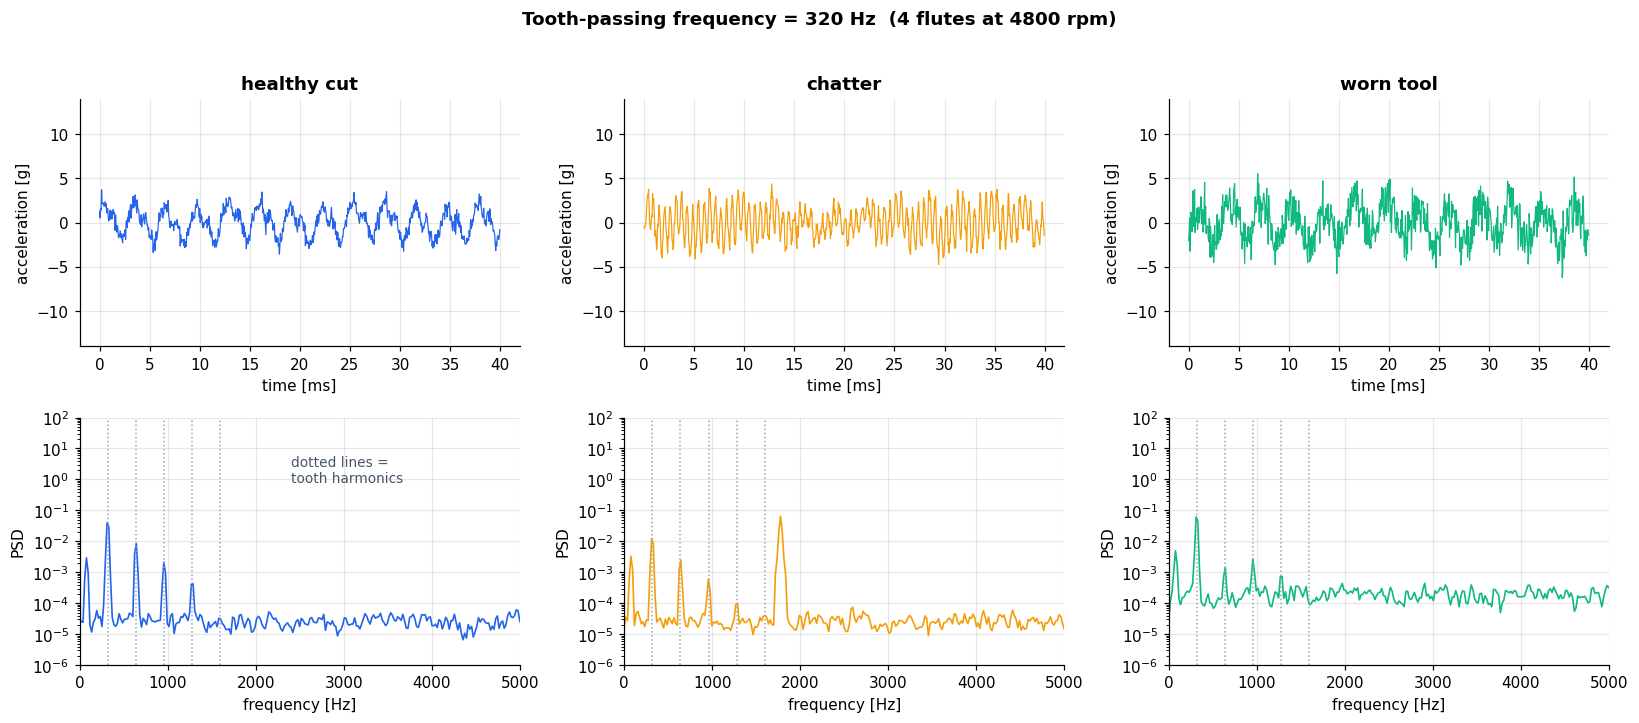

In [3]:
rng_demo = np.random.default_rng(3)
rpm, teeth, amp, load = REGIMES["semi_finish"]
x_ok,  f_tp = make_window(rng_demo, rpm, teeth, amp)
x_ch,  _    = make_window(rng_demo, rpm, teeth, amp, chatter=1.0)
x_wear, _   = make_window(rng_demo, rpm, teeth, amp * 1.25, wear=1.1)

fig, axes = plt.subplots(2, 3, figsize=(15, 6.4))
t_ms = np.arange(NS) / FS * 1e3
for j, (x, name) in enumerate([(x_ok, "healthy cut"), (x_ch, "chatter"), (x_wear, "worn tool")]):
    axes[0, j].plot(t_ms[:800], x[:800], lw=.8, color=PALETTE[j])
    axes[0, j].set_title(name, fontweight="bold"); axes[0, j].set_xlabel("time [ms]")
    axes[0, j].set_ylabel("acceleration [g]"); axes[0, j].set_ylim(-14, 14)

    f, P = sig.welch(x, FS, nperseg=1024)
    axes[1, j].semilogy(f, P, lw=1.1, color=PALETTE[j])
    for h in range(1, 6):                                    # mark the tooth harmonics
        axes[1, j].axvline(h * f_tp, color="#94a3b8", ls=":", lw=1)
    axes[1, j].set_xlim(0, 5000); axes[1, j].set_xlabel("frequency [Hz]")
    axes[1, j].set_ylabel("PSD"); axes[1, j].set_ylim(1e-6, 1e2)
axes[1, 0].text(2400, 8e-1, "dotted lines =\ntooth harmonics", fontsize=9, color="#475569")
fig.suptitle(f"Tooth-passing frequency = {f_tp:.0f} Hz  (4 flutes at 4800 rpm)",
             fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

Read the bottom row carefully:

- **healthy** — the peaks sit on the dotted tooth-harmonic lines;
- **chatter** — a large peak appears *away* from the lines, near 1.75 kHz, where a structural
  mode of the machine lives. In the time trace above it you can see *something* has changed,
  but only the spectrum tells you what;
- **worn tool** — no new tone, but the whole floor lifts and the 2× harmonic grows.

That observation dictates the feature set.

## 1.2 Why we cannot just cluster the raw signal

A tempting shortcut is to hand DBSCAN the waveform itself: 4096 numbers per window. The
reason it fails is worth *measuring* rather than asserting.

**Phase.** Two cuts in the same regime, sampled a millisecond apart, produce completely
different sample vectors — every sinusoid sits at a different phase. Euclidean distance
between raw waveforms therefore measures *phase alignment*, not similarity of machining
condition.

Density clustering needs points of the same kind to be closer to one another than to points
of a different kind. So let us measure exactly that: mean distance between windows **from the
same regime** versus **from different regimes**. Call the second divided by the first the
**contrast ratio**. Near 1.0 means there is no structure for any density method to find.

In [4]:
from scipy.spatial.distance import pdist, squareform

rng = np.random.default_rng(RANDOM_STATE)
raw_demo, demo_lbl = [], []
for name in REGIMES:
    rpm, teeth, amp, load = REGIMES[name]
    for _ in range(60):
        raw_demo.append(make_window(rng, rpm, teeth, amp * rng.normal(1, .055))[0])
        demo_lbl.append(name)
RAW = np.array(raw_demo)
demo_lbl = np.array(demo_lbl)


def contrast_ratio(M, labels):
    """mean between-group distance / mean within-group distance"""
    D = squareform(pdist(M))
    iu = np.triu_indices(len(M), k=1)
    same = labels[iu[0]] == labels[iu[1]]
    return D[iu][~same].mean() / D[iu][same].mean()


d_raw = NearestNeighbors(n_neighbors=11).fit(RAW).kneighbors(RAW)[0][:, -1]
print(f"raw waveform space : {RAW.shape[1]} dimensions, {len(RAW)} windows, 3 regimes")
print(f"  contrast ratio   : {contrast_ratio(RAW, demo_lbl):.2f}    (1.0 = no usable structure)")

lab_raw = DBSCAN(eps=np.median(d_raw), min_samples=10).fit_predict(RAW)
print(f"  DBSCAN           : {len(set(lab_raw) - {-1})} clusters, "
      f"{(lab_raw == -1).sum()} of {len(RAW)} windows called noise")

raw waveform space : 4096 dimensions, 180 windows, 3 regimes
  contrast ratio   : 1.12    (1.0 = no usable structure)
  DBSCAN           : 2 clusters, 60 of 180 windows called noise


A contrast ratio of about **1.1**: two windows from *different* cutting regimes are barely
further apart than two windows from the *same* regime. The regimes are physically miles apart
— 2400 rpm against 9000 rpm — yet in waveform space that difference is buried under phase.
DBSCAN duly fails to recover them.

We will recompute this number after feature extraction in §2.2 and watch it move.

---
# 2. Feature extraction

Six features per window — all standard in machine-tool condition monitoring:

| feature | definition | sensitive to |
|---|---|---|
| `rms_g` | $\sqrt{\overline{x^2}}$ | overall vibration energy → cutting severity |
| `crest` | $\max\lvert x\rvert / \text{RMS}$ | impulsiveness — chipped edges, impacts |
| `kurtosis` | 4th standardised moment | peakiness of the amplitude distribution |
| `spec_centroid_hz` | $\sum fP(f)/\sum P(f)$ | where the energy sits in frequency |
| `nonharmonic_ratio` | fraction of spectral energy **above 800 Hz and away from tooth harmonics** | **chatter** — the purpose-built feature |
| `spindle_load_pct` | from the CNC controller | which regime / how hard the cut |

`nonharmonic_ratio` is the one worth dwelling on. It encodes the domain knowledge we read off
the spectra above: *healthy milling puts its energy on the tooth harmonics; chatter does not.*
A generic feature set would miss chatter; this one is designed to catch it.

In [5]:
def extract_features(x, f_tp, spindle_load):
    """Six condition-monitoring features from one accelerometer window."""
    rms = float(np.sqrt(np.mean(x ** 2)))
    peak = float(np.max(np.abs(x)))

    f, P = sig.welch(x, FS, nperseg=512)
    P = P / P.sum()                                    # normalise to a distribution
    centroid = float((f * P).sum())

    harmonic = np.zeros_like(f, dtype=bool)            # +-90 Hz around each tooth harmonic
    for h in range(1, 9):
        harmonic |= np.abs(f - h * f_tp) < 90
    nonharmonic = float(P[~harmonic & (f > 800)].sum())

    return dict(rms_g=rms,
                crest=peak / rms,
                kurtosis=float(stats.kurtosis(x)),
                spec_centroid_hz=centroid,
                nonharmonic_ratio=nonharmonic,
                spindle_load_pct=spindle_load)

FEATURES = ["rms_g", "crest", "kurtosis", "spec_centroid_hz",
            "nonharmonic_ratio", "spindle_load_pct"]

In [6]:
def make_shift(seed=RANDOM_STATE):
    """One shift of machining: 610 healthy windows plus chatter and worn-tool events."""
    rng = np.random.default_rng(seed)
    rows, truth = [], []

    for name, k in [("roughing", 200), ("semi_finish", 220), ("finishing", 190)]:
        rpm, teeth, amp, load = REGIMES[name]
        for _ in range(k):
            ld = load * rng.normal(1.0, 0.035)
            x, f_tp = make_window(rng, rpm, teeth, amp * rng.normal(1.0, 0.055))
            rows.append(extract_features(x, f_tp, ld)); truth.append(name)

    for _ in range(22):                                       # chatter events
        name = rng.choice(["semi_finish", "finishing", "roughing"], p=[.40, .45, .15])
        rpm, teeth, amp, load = REGIMES[name]
        x, f_tp = make_window(rng, rpm, teeth, amp * rng.normal(1, .05),
                              chatter=rng.uniform(0.85, 1.15))
        rows.append(extract_features(x, f_tp, load * rng.normal(1.03, .04)))
        truth.append("chatter")

    for _ in range(18):                                       # worn tool, late in the shift
        name = rng.choice(["roughing", "semi_finish"], p=[.55, .45])
        rpm, teeth, amp, load = REGIMES[name]
        x, f_tp = make_window(rng, rpm, teeth, amp * rng.normal(1.25, .07),
                              wear=rng.uniform(0.8, 1.4))
        rows.append(extract_features(x, f_tp, load * rng.normal(1.16, .04)))
        truth.append("worn_tool")

    df = pd.DataFrame(rows)
    df["true_state"] = truth                                   # for SCORING ONLY
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

df = make_shift()
print(df.shape)
df.head()

(650, 7)


,rms_g,crest,kurtosis,spec_centroid_hz,nonharmonic_ratio,spindle_load_pct,true_state
0,1.349404,2.642578,-0.962524,951.359118,0.099610,52.027698,semi_finish
1,1.363771,2.759976,-0.694787,939.544478,0.097544,52.319577,semi_finish
2,2.642908,2.779573,-0.598458,770.930710,0.102306,73.881107,roughing
3,2.623400,2.936623,-0.684835,797.567743,0.108720,76.628765,roughing
4,0.653030,2.717835,-0.870142,1270.657391,0.099926,31.771218,finishing


In [7]:
df.groupby("true_state")[FEATURES].mean().round(3)

,rms_g,crest,kurtosis,spec_centroid_hz,nonharmonic_ratio,spindle_load_pct
true_state,,,,,,
chatter,1.654,2.936,-0.583,1779.635,0.762,49.432
finishing,0.727,2.794,-0.739,1240.307,0.097,30.950
roughing,2.663,2.808,-0.721,777.414,0.105,78.182
semi_finish,1.464,2.807,-0.729,948.660,0.100,52.139
worn_tool,3.488,3.321,-0.341,1936.632,0.293,79.748


## 2.2 The contrast ratio, revisited

Same measurement as in §1.2, now in the six-dimensional standardised feature space.

In [8]:
demo_feats = []
rng = np.random.default_rng(RANDOM_STATE)
for name in REGIMES:
    rpm, teeth, amp, load = REGIMES[name]
    for _ in range(60):
        x, f_tp = make_window(rng, rpm, teeth, amp * rng.normal(1, .055))
        demo_feats.append(extract_features(x, f_tp, load * rng.normal(1, .035)))
FEA = StandardScaler().fit_transform(pd.DataFrame(demo_feats)[FEATURES].values)

print(f"raw waveform space (4096-D) : contrast ratio {contrast_ratio(RAW, demo_lbl):.2f}")
print(f"feature space (6-D, scaled) : contrast ratio {contrast_ratio(FEA, demo_lbl):.2f}")

raw waveform space (4096-D) : contrast ratio 1.12
feature space (6-D, scaled) : contrast ratio 1.91


The ratio rises from 1.12 to 1.91 — a 1.7-fold increase, and the difference between
"no usable structure" and "clearly separated groups". That is the entire contribution of
feature extraction, in one number: it converts a space where the regimes are invisible into one where they are
separated. **Nothing about DBSCAN changed** — only what we handed it.

## 2.3 No single feature does the job

Look down the columns of that table before clustering. This is the most important
observation in the notebook:

- **`rms_g`** separates the three cutting regimes beautifully (0.73 / 1.46 / 2.67 g) — but it
  is useless for chatter. Incipient chatter *redistributes* energy rather than adding much of
  it, so a chattering finishing pass has roughly the RMS of a healthy semi-finish pass. An
  RMS alarm would either miss it or fire constantly on legitimate roughing.
- **`nonharmonic_ratio`** is the opposite: it separates healthy (≈ 0.10) from worn tools
  (≈ 0.29) from chatter (≈ 0.76) — but says nothing at all about which regime a cut is in.
- **`kurtosis`** is *negative* everywhere (≈ −0.7). That is not a bug: a signal dominated by a
  few strong sinusoids is **sub-Gaussian**. Tool wear pushes it toward zero as broadband
  content grows, but chatter — being yet another strong tone — barely moves it. A kurtosis
  alarm alone would miss chatter completely.

So no threshold on any single channel gives a useful classifier, and the two things we care
about are legible in *different* features. DBSCAN needs no threshold: it works on the
**joint geometry** of all six.

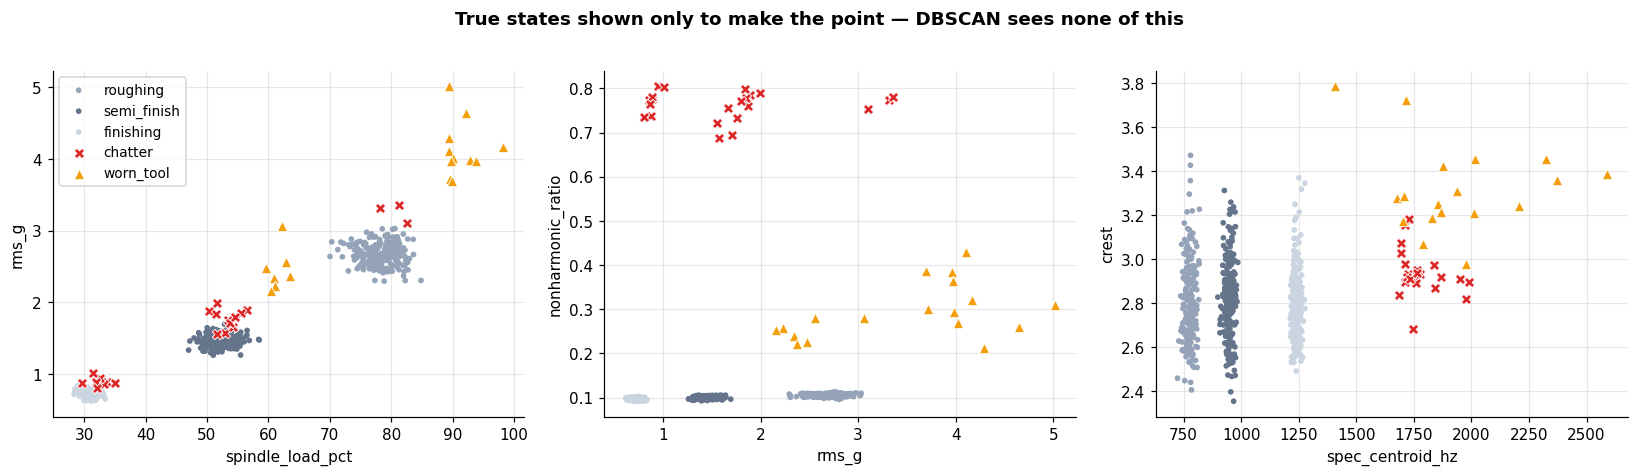

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
style = {"roughing": ("o", "#94a3b8"), "semi_finish": ("o", "#64748b"), "finishing": ("o", "#cbd5e1"),
         "chatter": ("X", "#dc2626"), "worn_tool": ("^", "#f59e0b")}
pairs = [("spindle_load_pct", "rms_g"), ("rms_g", "nonharmonic_ratio"),
         ("spec_centroid_hz", "crest")]
for ax, (a, b) in zip(axes, pairs):
    for state, (mk, c) in style.items():
        s = df.true_state == state
        ax.scatter(df[a][s], df[b][s], s=46 if mk != "o" else 14, marker=mk, c=c,
                   ec="white" if mk != "o" else "none", lw=.6,
                   label=state if ax is axes[0] else None, zorder=4 if mk != "o" else 2)
    ax.set_xlabel(a); ax.set_ylabel(b)
axes[0].legend(fontsize=9, loc="upper left")
fig.suptitle("True states shown only to make the point — DBSCAN sees none of this",
             fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

---
# 3. Clustering

Same recipe as the main lecture: standardise, fix MinPts, read ε off the k-distance knee.
With $d = 6$ features the rule of thumb MinPts $\ge 2d$ gives **MinPts = 12**.

In [10]:
def k_distance(X, k):
    """Sorted distance from each point to its k-th nearest neighbour."""
    d, _ = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X)
    return np.sort(d[:, -1])


def plot_k_distance(X, k, eps=None, ax=None, title=None):
    kd = k_distance(X, k)
    ax = ax or plt.subplots(figsize=(7.5, 4.2))[1]
    ax.plot(kd, lw=2.2, color="#2563eb")
    if eps is not None:
        ax.axhline(eps, color=NOISE_C, ls="--", lw=1.6)
        ax.text(0.02 * len(kd), eps * 1.06, f"chosen eps = {eps}", color=NOISE_C, fontweight="bold")
    ax.set_xlabel("points sorted by k-distance")
    ax.set_ylabel(f"{k}-NN distance (standardised units)")
    ax.set_title(title or f"Sorted {k}-distance plot", fontweight="bold")
    return ax


def cluster_report(X, labels, truth=None, healthy_mask=None):
    """Standard summary: cluster count, noise rate, silhouette, and -- when ground
    truth is available -- regime ARI plus anomaly precision/recall."""
    m = labels != -1
    out = {"n_clusters": len(set(labels) - {-1}),
           "n_noise": int((~m).sum()),
           "noise_pct": round(100 * (~m).mean(), 1)}
    if len(set(labels[m])) > 1:
        out["silhouette"] = round(silhouette_score(X[m], labels[m]), 3)
    if truth is not None and healthy_mask is not None:
        h = healthy_mask
        if (h & m).sum() and len(set(labels[h & m])) > 1:
            out["ARI_regimes"] = round(adjusted_rand_score(truth[h & m], labels[h & m]), 3)
        out["anomaly_precision"] = round(precision_score(~h, ~m, zero_division=0), 3)
        out["anomaly_recall"] = round(recall_score(~h, ~m, zero_division=0), 3)
    return out


def scatter_labels(ax, XY, labels, title="", s=20, legend=True, names=None):
    for k in sorted(set(labels) - {-1}):
        sel = labels == k
        lbl = (names or {}).get(k, f"cluster {k}")
        ax.scatter(*XY[sel].T, s=s, c=PALETTE[k % len(PALETTE)], ec="none", alpha=.85,
                   label=f"{lbl}  (n={sel.sum()})")
    sel = labels == -1
    if sel.any():
        ax.scatter(*XY[sel].T, s=s * 4, c=NOISE_C, marker="X", ec="white", lw=.7, zorder=5,
                   label=f"noise, label = -1  (n={sel.sum()})")
    ax.set_title(title, fontweight="bold")
    if legend:
        ax.legend(fontsize=9)
    return ax

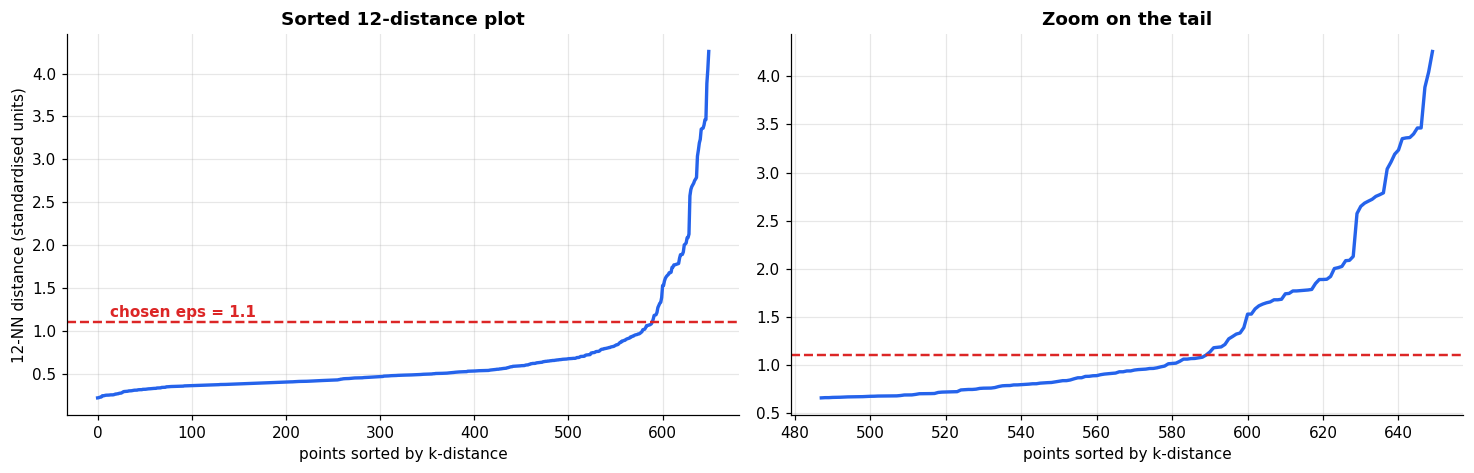

50th percentile of the 12-NN distance: 0.48
80th percentile of the 12-NN distance: 0.72
88th percentile of the 12-NN distance: 0.95
92th percentile of the 12-NN distance: 1.32
94th percentile of the 12-NN distance: 1.74
96th percentile of the 12-NN distance: 2.00
98th percentile of the 12-NN distance: 2.79


In [11]:
X = StandardScaler().fit_transform(df[FEATURES].values)
MIN_SAMPLES = 12
EPS = 1.1

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
plot_k_distance(X, MIN_SAMPLES, eps=EPS, ax=axes[0], title="Sorted 12-distance plot")
kd = k_distance(X, MIN_SAMPLES)
axes[1].plot(range(int(.75 * len(kd)), len(kd)), kd[int(.75 * len(kd)):], lw=2.2, color="#2563eb")
axes[1].axhline(EPS, color=NOISE_C, ls="--", lw=1.6)
axes[1].set_title("Zoom on the tail", fontweight="bold"); axes[1].set_xlabel("points sorted by k-distance")
fig.tight_layout(); plt.show()

for p in [50, 80, 88, 92, 94, 96, 98]:
    print(f"{p:2d}th percentile of the 12-NN distance: {np.percentile(kd, p):.2f}")

The curve is flat out to about the 80th percentile (0.72), then bends upward through
0.95 at the 88th and 1.32 at the 92nd. We take **ε = 1.1**, in the bend.

A single reading of a knee is never quite convincing on its own, so confirm it the way the
main lecture recommends — by checking that the answer is **stable** across a range of ε:

In [12]:
rows = []
for eps in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]:
    lb = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X)
    rows.append({"eps": eps, **cluster_report(X, lb,
                 truth=df.true_state.values,
                 healthy_mask=df.true_state.isin(
                     ["roughing", "semi_finish", "finishing"]).values)})
pd.DataFrame(rows).set_index("eps")

,n_clusters,n_noise,noise_pct,silhouette,ARI_regimes,anomaly_precision,anomaly_recall
eps,,,,,,,
0.7,3,67,10.3,0.394,1.000,0.597,1.0
0.8,3,56,8.6,0.386,1.000,0.714,1.0
0.9,3,51,7.8,0.381,1.000,0.784,1.0
1.0,3,46,7.1,0.376,1.000,0.870,1.0
1.1,3,45,6.9,0.375,1.000,0.889,1.0
1.2,3,45,6.9,0.375,1.000,0.889,1.0
1.3,3,41,6.3,0.370,1.000,0.976,1.0
1.4,3,40,6.2,0.368,1.000,1.000,1.0
1.5,3,28,4.3,0.429,0.567,1.000,0.7


Every ε from 0.7 to 1.4 returns **the same three clusters with ARI 1.000 and anomaly recall
1.000**; only the false-alarm count moves. That plateau — not the knee alone — is the evidence
that the three cutting regimes are real structure rather than an artefact of one lucky ε.

---
# 3. Fitting DBSCAN

In [13]:
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X)
labels = db.labels_

healthy = df.true_state.isin(["roughing", "semi_finish", "finishing"]).values
report = cluster_report(X, labels, truth=df.true_state.values, healthy_mask=healthy)
for k, v in report.items():
    print(f"{k:>18s} : {v}")

print()
print(pd.crosstab(pd.Series(df.true_state.values, name="true_state"),
                  pd.Series(labels, name="dbscan_label")))

        n_clusters : 3
           n_noise : 45
         noise_pct : 6.9
        silhouette : 0.375
       ARI_regimes : 1.0
 anomaly_precision : 0.889
    anomaly_recall : 1.0

dbscan_label  -1    0    1    2
true_state                     
chatter       22    0    0    0
finishing      1    0    0  189
roughing       4    0  196    0
semi_finish    0  220    0    0
worn_tool     18    0    0    0


**Three clusters — the three cutting regimes, recovered exactly (ARI = 1.000) — and every
chatter and worn-tool window flagged as noise (recall = 1.000).**

## 3.1 On that silhouette score

The silhouette here is about **0.37**, which looks poor next to the 0.81 of the main lecture.
It is not a problem, and explaining why is a useful exercise:

- Silhouette compares each point's mean distance to its own cluster against the nearest other
  cluster. It **rewards compact, roughly spherical clusters**.
- Our regime clusters are *elongated*: `crest` and `kurtosis` are noisy estimators, so each
  regime is a long thin cigar in those directions while being razor-tight in `rms_g` and
  `spindle_load_pct`.

A modest silhouette on a density clustering means "the clusters are not ball-shaped", not
"the clustering is wrong". The crosstab above is the real evidence. **Do not tune ε to
maximise silhouette** — you would be optimising for a shape assumption DBSCAN was chosen
precisely to avoid.

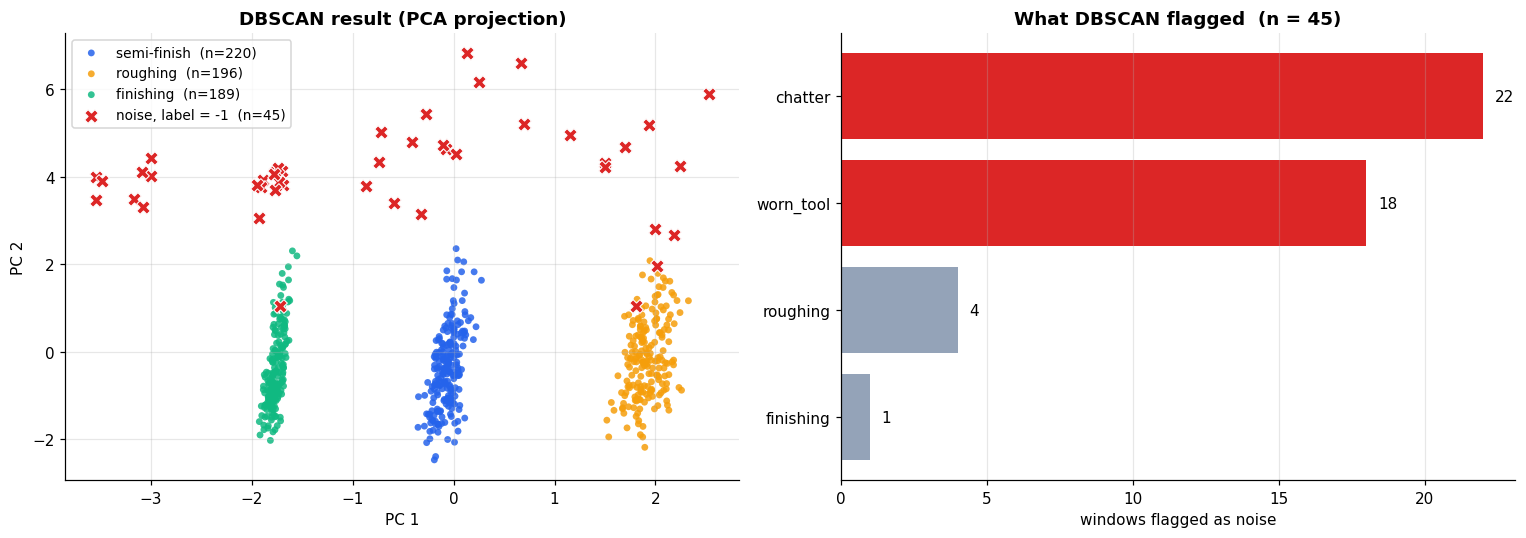

In [14]:
Z = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
names = {}
order = (pd.Series(df.spindle_load_pct.values).groupby(labels).mean()
           .drop(index=-1, errors="ignore").sort_values().index)
for rank, k in enumerate(order):
    names[k] = ["finishing", "semi-finish", "roughing"][rank]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_labels(axes[0], Z, labels, "DBSCAN result (PCA projection)", names=names)
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")

# what the flagged windows actually are
flagged = df[labels == -1]
counts = flagged.true_state.value_counts()
axes[1].barh(counts.index[::-1], counts.values[::-1],
             color=[NOISE_C if s in ("chatter", "worn_tool") else "#94a3b8"
                    for s in counts.index[::-1]])
for i, (s, v) in enumerate(zip(counts.index[::-1], counts.values[::-1])):
    axes[1].text(v + 0.4, i, str(v), va="center", fontsize=10)
axes[1].set_title(f"What DBSCAN flagged  (n = {len(flagged)})", fontweight="bold")
axes[1].set_xlabel("windows flagged as noise"); axes[1].grid(axis="y")
fig.tight_layout(); plt.show()

The two grey bars — five windows in total — are healthy cuts in the thin tails of their
regimes, the false-alarm cost of catching all 40 genuine events. On a machine tool that is a reasonable trade: five
extra glances at a surface finish against zero missed chatter events.

## 3.2 Separating the two fault types

DBSCAN gave us one bucket labelled `-1`. An operator needs to know *which* fault. Because we
designed `nonharmonic_ratio` to encode chatter physics, the split is trivial once the
anomalies are isolated — and this two-stage pattern (**unsupervised triage → physics-based
diagnosis**) is how these systems are actually built.

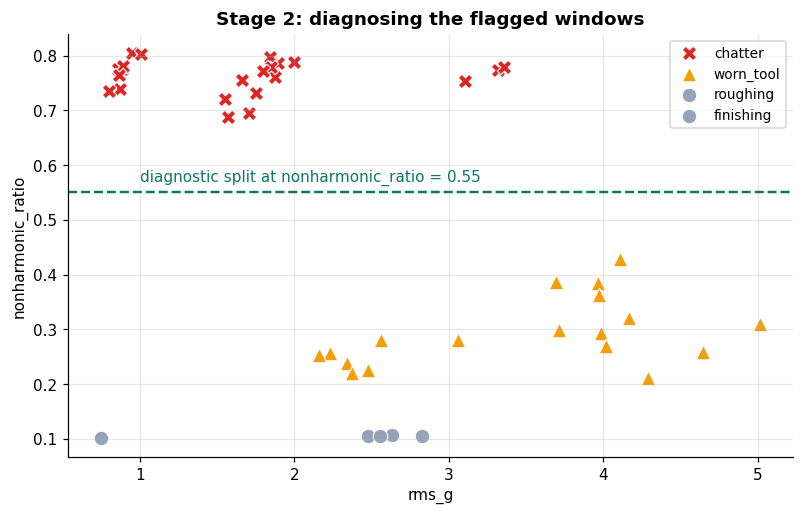

diagnosis   chatter  tool wear / other
true_state                            
chatter          22                  0
finishing         0                  1
roughing          0                  4
worn_tool         0                 18


In [15]:
flagged = df[labels == -1].copy()
flagged["diagnosis"] = np.where(flagged.nonharmonic_ratio > 0.55, "chatter", "tool wear / other")

fig, ax = plt.subplots(figsize=(8.5, 5))
for state, (mk, c) in [("chatter", ("X", "#dc2626")), ("worn_tool", ("^", "#f59e0b")),
                       ("roughing", ("o", "#94a3b8")), ("semi_finish", ("o", "#94a3b8")),
                       ("finishing", ("o", "#94a3b8"))]:
    s = flagged.true_state == state
    if s.any():
        ax.scatter(flagged.rms_g[s], flagged.nonharmonic_ratio[s], s=90, marker=mk, c=c,
                   ec="white", lw=.7, label=state)
ax.axhline(0.55, color="#0f766e", ls="--", lw=1.6)
ax.text(1.0, 0.57, "diagnostic split at nonharmonic_ratio = 0.55", color="#0f766e", fontsize=10)
ax.set_xlabel("rms_g"); ax.set_ylabel("nonharmonic_ratio")
ax.set_title("Stage 2: diagnosing the flagged windows", fontweight="bold")
ax.legend(fontsize=9); plt.show()

print(pd.crosstab(flagged.true_state, flagged.diagnosis))

---
# 4. What if we had chosen worse features?

The claim at the top of this notebook was that the features, not the algorithm, decide what
you can detect. Here is the experiment: re-run the identical DBSCAN pipeline on feature
subsets, giving each one the **same alarm budget** (tune ε until roughly 45 windows are
flagged) so the comparison is fair.

In [16]:
def alarms_at_budget(feats, budget=45, min_samples=12):
    """Tune eps so that ~`budget` windows are flagged, then report what was caught."""
    Xs = StandardScaler().fit_transform(df[feats].values)
    best = None
    for eps in np.arange(0.15, 4.0, 0.01):
        lb = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xs)
        nz = int((lb == -1).sum())
        if best is None or abs(nz - budget) < abs(best[1] - budget):
            best = (eps, nz, lb)
    eps, nz, lb = best
    caught = {s: round(float((lb == -1)[df.true_state.values == s].mean()), 2)
              for s in ["chatter", "worn_tool"]}
    return dict(features=len(feats), eps=round(eps, 2), alarms=nz,
                clusters=len(set(lb) - {-1}),
                chatter_recall=caught["chatter"], wear_recall=caught["worn_tool"])

subsets = {
    "all six": FEATURES,
    "drop nonharmonic_ratio (keep centroid)": [f for f in FEATURES if f != "nonharmonic_ratio"],
    "drop both frequency features": ["rms_g", "crest", "kurtosis", "spindle_load_pct"],
    "time-domain only (rms, crest, kurtosis)": ["rms_g", "crest", "kurtosis"],
    "rms + spindle load only": ["rms_g", "spindle_load_pct"],
}
pd.DataFrame([{"feature set": k, **alarms_at_budget(v)} for k, v in subsets.items()]).set_index("feature set")

,features,eps,alarms,clusters,chatter_recall,wear_recall
feature set,,,,,,
all six,6,1.04,45,3,1.00,1.00
drop nonharmonic_ratio (keep centroid),5,1.04,45,3,1.00,1.00
drop both frequency features,4,0.68,45,3,0.00,1.00
"time-domain only (rms, crest, kurtosis)",3,0.66,44,1,0.00,0.94
rms + spindle load only,2,0.15,28,3,0.36,1.00


Read the `chatter_recall` column down the table. The algorithm and the parameters are identical in every
row, and ε is tuned to hold the alarm count near 45 — only the feature set changes. (The last row never reaches 45 alarms
anywhere in the ε range searched — it plateaus at 28, essentially the worn-tool windows, which
are the only thing two features can still see.)

- **All six** — everything caught.
- **Drop `nonharmonic_ratio`, keep `spec_centroid_hz`** — chatter is still caught. The two
  features encode the same physics (energy has moved to a high, non-harmonic frequency), so
  they are partly redundant. Redundancy is a *virtue* in a monitoring system: lose one
  channel and you degrade instead of going blind.
- **Drop both frequency-domain features** — chatter detection collapses, because nothing left
  in the feature set can see where the energy sits in frequency.
- **RMS and spindle load only** — the three regimes are still recovered (those two features
  are exactly what defines a regime), and tool wear is still caught, because a blunt tool
  genuinely raises forces. But incipient chatter is largely missed: it lives inside the RMS
  envelope of a neighbouring regime.

> **This is the whole point.** Tuning ε buys a few percent. Choosing to compute a spectrum at
> all is what makes chatter detectable — and that decision came from understanding milling,
> not from understanding clustering. When a clustering "doesn't work", the first question is
> not *which algorithm*; it is *what am I measuring*.

---
# 5. Summary

1. DBSCAN never sees your signal, only your features. On rotating machinery those features
   come from **windowed time- and frequency-domain analysis**, and they must be phase-invariant.
2. Clustering raw waveforms fails for two independent reasons: **phase sensitivity** and
   **distance concentration** in high dimensions.
3. **Frequency-domain features are what make chatter detectable at all.** Incipient chatter
   hides inside the normal RMS range; it is only obvious once you ask *where* the energy sits.
4. Confirm a k-distance knee with a **stability plateau** — here every ε from 0.7 to 1.4
   returns the same three regimes and the same recall.
5. **A low silhouette on elongated clusters is not a failure.** Do not tune ε to maximise it.
6. Practical architecture: **DBSCAN triages** (which windows are abnormal), a **physics rule
   diagnoses** (which fault it is).

---
# 6. Exercises

1. **Window length.** Re-run with `NS = 1024` and with `NS = 8192`. Kurtosis and crest factor
   are noisier on short windows — how does the k-distance gap and the false-alarm count change?
2. **Severe chatter.** Raise the chatter amplitude factor from 1.15 to 3.0 (fully developed
   chatter). Re-run the §4 ablation: RMS alone now finds it. Explain why *incipient* detection
   is the harder and more valuable problem.
3. **Add a fault.** Add a **broken-flute** condition: one of the four teeth removed, which
   creates a strong component at the *spindle* frequency $N/60$ rather than at $f_{TP}$.
   Which existing feature catches it? If none does, design one — and note that the chatter
   frequency guard in `chatter_frequency` hints at the trap: a fault tone that lands on a
   tooth harmonic is invisible to `nonharmonic_ratio`.
4. **Frequency resolution.** `extract_features` uses `nperseg=512`. Try 256 and 2048. What
   happens to `nonharmonic_ratio` when the harmonic-rejection window (±90 Hz) is narrower than
   the spectral resolution?
5. **Regime-relative alarms.** Instead of clustering all windows together, cluster within each
   regime separately. Does that catch the worn-tool windows earlier?
6. **Compare.** Run `HDBSCAN(min_cluster_size=20)` on the same six features. Does it agree
   with DBSCAN about which windows are abnormal?
7. **Scaling.** `spec_centroid_hz` spans hundreds of Hz while `nonharmonic_ratio` is in [0, 1].
   Confirm what happens without `StandardScaler`, and explain it in terms of the ε-ball.

### References

- Ester, Kriegel, Sander & Xu, *A Density-Based Algorithm for Discovering Clusters…*, KDD-96.
- Y. Altintas, *Manufacturing Automation: Metal Cutting Mechanics, Machine Tool Vibrations, and
  CNC Design*, 2nd ed., CUP 2012 — chatter theory and stability lobes.
- R. B. Randall, *Vibration-based Condition Monitoring*, Wiley 2011 — the standard feature set.
- ISO 10816 / ISO 20816 — vibration evaluation on non-rotating parts.

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>